# CHƯƠNG 9: PHÂN TÍCH PHÂN CỤM (CLUSTER ANALYSIS)

Trong các chương trước, chúng ta đã làm việc với các bài toán có sự hiện diện của biến mục tiêu (Dependence Methods) hoặc tìm cấu trúc nhân tố ẩn (Factor Analysis). Tuy nhiên, trong thực tế kinh doanh, đặc biệt là Marketing, chúng ta thường đối mặt với một câu hỏi mở: "Tập khách hàng khổng lồ này thực chất bao gồm những nhóm người nào? Họ có đặc điểm gì chung?". 

Đây là lúc chúng ta cần đến **Phân tích Phân cụm (Cluster Analysis)** — một nhánh cốt lõi của **Học không giám sát (Unsupervised Learning)**. Mục tiêu của phân cụm là nhóm các quan sát sao cho các cá thể trong cùng một nhóm cực kỳ giống nhau (high intra-cluster similarity) và các nhóm khác nhau thì cực kỳ khác biệt (low inter-cluster similarity).

---

## 9.1. Bài toán Phân khúc: Nghệ thuật cá nhân hóa trong Marketing

Trong kỷ nguyên Marketing 5.0, chiến lược "Marketing đại trà" (Mass Marketing) — coi mọi khách hàng như nhau — đã trở nên lỗi thời. Thay vào đó, các doanh nghiệp hướng tới **Phân khúc khách hàng (Customer Segmentation)** để tối ưu hóa nguồn lực và cá nhân hóa trải nghiệm.

### 9.1.1. Bản chất của Unsupervised Learning trong Phân khúc
Khác với bài toán Chấm điểm tín dụng (đã có nhãn "Vỡ nợ" hay "Không vỡ nợ" để học), bài toán phân khúc không có nhãn trước. Chúng ta không biết trước khách hàng A thuộc nhóm "Tiềm năng" hay "Rủi ro rời bỏ". Thuật toán phân cụm phải tự mình khám phá ra cấu trúc hình học của đám mây dữ liệu để vạch ra ranh giới giữa các nhóm.

### 9.1.2. Ví dụ thực tế: Mô hình RFM trong Bán lẻ và Ngân hàng
Một trong những ứng dụng kinh điển của phân cụm đa biến là dựa trên mô hình **RFM**:
- **Recency (R):** Ngày gần nhất khách hàng giao dịch.
- **Frequency (F):** Tần suất giao dịch trong một khoảng thời gian.
- **Monetary (M):** Tổng số tiền khách hàng đã chi tiêu/giao dịch.

Bằng cách áp dụng phân cụm trên không gian 3 chiều (R, F, M), thuật toán có thể tự động tách biệt ra các nhóm như:
1. **Champions:** R thấp (vừa mới mua), F cao, M cao. Đây là những khách hàng trung thành nhất.
2. **At Risk:** R rất cao (đã lâu không quay lại), F cao, M cao. Những khách hàng lớn có nguy cơ rời bỏ, cần chương trình chăm sóc đặc biệt.
3. **Low-Value:** R cao, F thấp, M thấp. Nhóm khách hàng vãng lai, không cần ưu tiên nguồn lực.

Việc phân cụm thành công giúp marketer chuyển từ việc gửi tin nhắn rác sang việc gửi đúng thông điệp, đúng đối tượng, đúng thời điểm.

---

## 9.2. Thuật toán K-Means Clustering

K-Means là thuật toán phân cụm phổ biến nhất nhờ tính đơn giản, tốc độ tính toán nhanh và khả năng mở rộng mạnh mẽ. Đây là một thuật toán phân chia (partitioning algorithm) dựa trên việc cực tiểu hóa khoảng cách từ các điểm dữ liệu đến tâm của cụm.

### 9.2.1. Hàm mục tiêu: Within-Cluster Sum of Squares (WCSS)

Giả sử chúng ta muốn chia $N$ quan sát thành $K$ cụm $\{C_1, C_2, \dots, C_K\}$. Mỗi cụm $C_j$ được đại diện bởi một giá trị trung bình — gọi là **Tâm cụm (Centroid)**, ký hiệu là $\boldsymbol{\mu}_j$.

Mục tiêu của K-Means là tìm ra các cụm sao cho tổng bình phương khoảng cách Euclidean từ mỗi điểm đến tâm cụm tương ứng là nhỏ nhất. Hàm mục tiêu $J$ được định nghĩa:

$$J = \sum_{j=1}^{K} \sum_{\mathbf{x}_i \in C_j} ||\mathbf{x}_i - \boldsymbol{\mu}_j||^2$$

**Giải thích chi tiết các ký hiệu:**
- $K$: Số lượng cụm (phải được xác định trước).
- $C_j$: Tập hợp các điểm thuộc về cụm thứ $j$.
- $\mathbf{x}_i$: Vector dữ liệu của quan sát thứ $i$.
- $\boldsymbol{\mu}_j$: Vector trung bình (Centroid) của cụm $C_j$. Nó là trọng tâm hình học của cụm đó.
- $||\mathbf{x}_i - \boldsymbol{\mu}_j||^2$: Bình phương khoảng cách Euclidean đa chiều. 

Giá trị $J$ còn được gọi là **Inertia** hoặc **WCSS**. Giá trị này càng nhỏ, các cụm càng cô đặc.

---

### 9.2.2. Quy trình tối ưu hóa lặp (Expectation-Maximization)

Vì việc tìm kiếm cách phân cụm tối ưu toàn cục là một bài toán NP-hard, K-Means sử dụng một chiến lược lặp gồm 3 bước để tìm cực tiểu địa phương:

1. **Khởi tạo (Initialization):** Chọn ngẫu nhiên $K$ điểm dữ liệu làm các Centroid ban đầu.
2. **Bước Gán cụm (Assignment):** Với mỗi điểm dữ liệu $\mathbf{x}_i$, tính khoảng cách đến tất cả $K$ centroid. Gán $\mathbf{x}_i$ vào cụm có centroid gần nó nhất.
   $$C_j = \{ \mathbf{x}_i : ||\mathbf{x}_i - \boldsymbol{\mu}_j|| \le ||\mathbf{x}_i - \boldsymbol{\mu}_l||, \forall l=1\dots K \}$$
3. **Bước Cập nhật (Update):** Sau khi tất cả các điểm đã được gán nhãn, tính toán lại vị trí của các centroid bằng cách lấy trung bình cộng tọa độ của tất cả các điểm trong cụm đó.
   $$\boldsymbol{\mu}_j = \frac{1}{|C_j|} \sum_{\mathbf{x}_i \in C_j} \mathbf{x}_i$$

Thuật toán lặp lại bước 2 và 3 cho đến khi vị trí các centroid không còn thay đổi đáng kể hoặc đạt giới hạn vòng lặp.

---

### 9.2.3. Những hạn chế chí tử của K-Means truyền thống

Dù mạnh mẽ, K-Means mắc phải 3 nhược điểm lớn cần chuyên gia lưu ý:
1. **Định trước K:** Chúng ta phải biết trước số lượng cụm. Trong thực tế, việc này thường mang tính chủ quan (Sẽ giải quyết bằng phương pháp Elbow ở mục sau).
2. **Giả định Cụm Lồi (Spherical assumption):** K-Means hoạt động dựa trên khoảng cách Euclidean nên nó luôn cố gắng tạo ra các cụm hình cầu (hoặc hình khối lồi). Nếu dữ liệu thực tế có dạng hình trăng khuyết, hình lồng nhau, K-Means sẽ thất bại thảm hại.
3. **Nhạy cảm với Outliers:** Vì centroid là trung bình cộng, chỉ cần một điểm ngoại lai nằm rất xa cũng có thể kéo centroid lệch khỏi tâm thực sự của đám mây điểm, làm sai lệch ranh giới phân cụm.

### 9.2.4. Khởi tạo K-Means++: Chiến lược thông minh
Nếu khởi tạo $K$ centroid ban đầu quá gần nhau, thuật toán sẽ mất rất nhiều vòng lặp để hội tụ, hoặc tệ hơn là hội tụ về một nghiệm tồi. **K-Means++** giải quyết điều này bằng cách:
- Chọn centroid thứ nhất ngẫu nhiên.
- Chọn các centroid tiếp theo với xác suất tỷ lệ thuận với bình phương khoảng cách từ điểm đó đến centroid gần nhất đã chọn. 
- **Kết quả:** Các centroid ban đầu được đẩy ra xa nhau nhất có thể, bao phủ toàn bộ không gian dữ liệu ngay từ đầu.


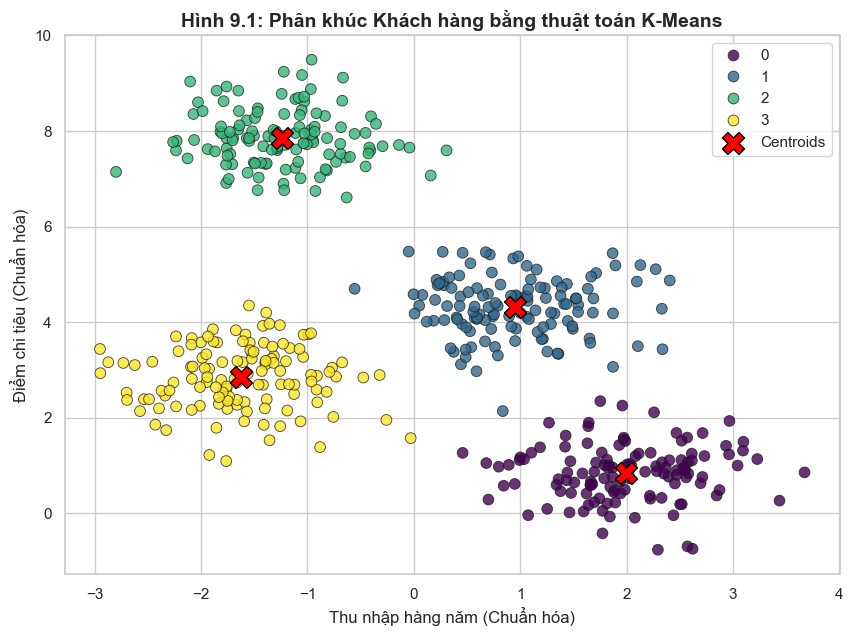

Tổng bình phương sai số trong cụm (Inertia/WCSS): 90.21


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# Thiết lập đồ họa học thuật
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ========================================================
# BƯỚC 1: GIẢ LẬP DỮ LIỆU MARKETING (N=500 khách hàng)
# Hai biến: Thu nhập hàng tháng (Income) và Điểm chi tiêu (Spending Score)
# ========================================================
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)
df = pd.DataFrame(X, columns=['Annual_Income', 'Spending_Score'])

# CHUẨN HÓA DỮ LIỆU: Bắt buộc vì K-Means dùng khoảng cách Euclidean
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ========================================================
# BƯỚC 2: HUẤN LUYỆN K-MEANS VỚI K=4
# ========================================================
# init='k-means++' là mặc định giúp hội tụ nhanh và ổn định hơn
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Thêm nhãn cụm vào dataframe gốc
df['Cluster'] = y_kmeans

# ========================================================
# BƯỚC 3: TRỰC QUAN HÓA KẾT QUẢ PHÂN KHÚC
# ========================================================
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', 
                hue='Cluster', palette='viridis', s=60, alpha=0.8, edgecolor='k')

# Vẽ các tâm cụm (Centroids)
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c='red', marker='X', 
            label='Centroids', edgecolor='black')

plt.title('Hình 9.1: Phân khúc Khách hàng bằng thuật toán K-Means', fontsize=14, fontweight='bold')
plt.xlabel('Thu nhập hàng năm (Chuẩn hóa)', fontsize=12)
plt.ylabel('Điểm chi tiêu (Chuẩn hóa)', fontsize=12)
plt.legend()
plt.show()

print(f"Tổng bình phương sai số trong cụm (Inertia/WCSS): {kmeans.inertia_:.2f}")

### Phân tích diễn giải Output Hình học:

1. **Các đám mây màu sắc (Clusters):** Mỗi màu đại diện cho một phân khúc khách hàng mà thuật toán tự động nhận diện. Bạn có thể thấy các ranh giới được phân chia khá rõ ràng. 
2. **Dấu 'X' màu đỏ (Centroids):** Đây là "khách hàng đại diện" cho mỗi nhóm. Trong marketing, chúng ta sẽ phân tích đặc điểm của 4 điểm đỏ này để xây dựng **Persona** (Hình mẫu khách hàng). Ví dụ: Cụm ở trên cùng bên trái có thu nhập thấp nhưng chi tiêu rất cao (nhóm khách hàng trẻ, ưa thích xu hướng).
3. **Inertia (WCSS):** Giá trị này cho biết mức độ "chặt chẽ" của các cụm. Khi chúng ta tăng $K$, giá trị này sẽ luôn giảm. Tuy nhiên, mục tiêu không phải là làm cho Inertia bằng 0 (mỗi điểm là 1 cụm), mà là tìm điểm cân bằng giữa số lượng cụm và độ cô đặc.

# 9.3. PHÂN CỤM PHÂN CẤP (HIERARCHICAL CLUSTERING)

Trong thực tế phân tích dữ liệu kinh tế, đôi khi cấu trúc của các nhóm không rời rạc mà tồn tại dưới dạng lồng ghép (Nested structure). Ví dụ: Trong một ngân hàng, nhóm "Khách hàng VIP" có thể bao gồm hai phân khúc nhỏ hơn là "VIP - Chủ doanh nghiệp" và "VIP - Nhà đầu tư cá nhân". Phân cụm phân cấp là kỹ thuật lý tưởng để khám phá những cấu trúc tầng thứ này mà không cần biết trước số lượng cụm $K$.

---

### 9.3.1. Cách tiếp cận Hợp nhất (Agglomerative - Bottom-up)

Đây là phương pháp phổ biến nhất trong phân cụm phân cấp. Quy trình hoạt động dựa trên nguyên lý tích tụ dần dần:
1. **Khởi tạo:** Coi mỗi quan sát (khách hàng) là một cụm riêng biệt. Nếu có $N$ quan sát, ta bắt đầu với $N$ cụm.
2. **Hợp nhất:** Tìm cặp cụm có khoảng cách "gần nhau nhất" và gộp chúng lại thành một cụm mới. Lúc này còn $N-1$ cụm.
3. **Lặp lại:** Tiếp tục quá trình tìm kiếm và hợp nhất cho đến khi toàn bộ dữ liệu chỉ còn lại một cụm duy nhất chứa tất cả các quan sát.

Trái tim của thuật toán này nằm ở định nghĩa về "Khoảng cách giữa hai cụm" — còn được gọi là các **Phương pháp liên kết (Linkage Methods)**.

---

### 9.3.2. Các phương pháp liên kết (Linkage Methods)

Gọi $D(A, B)$ là khoảng cách giữa cụm $A$ và cụm $B$. Tùy thuộc vào cách ta đo lường khoảng cách này, hình dáng của các cụm sẽ thay đổi hoàn toàn.

**1. Liên kết đơn (Single Linkage - Nearest Neighbor):**
$$D(A, B) = \min \{ d(a, b) : a \in A, b \in B \}$$
- Khoảng cách được tính bởi cặp phần tử gần nhau nhất giữa hai cụm.
- **Đặc điểm:** Dễ dẫn đến hiện tượng "Chaining" (Chuỗi dây chuyền), nơi các cụm bị kéo dài và có hình dạng kỳ dị.

**2. Liên kết đầy đủ (Complete Linkage - Farthest Neighbor):**
$$D(A, B) = \max \{ d(a, b) : a \in A, b \in B \}$$
- Khoảng cách được tính bởi cặp phần tử xa nhau nhất.
- **Đặc điểm:** Thường tạo ra các cụm có đường kính tương đồng và cô đặc hơn.

**3. Liên kết trung bình (Average Linkage - UPGMA):**
$$D(A, B) = \frac{1}{|A| \cdot |B|} \sum_{a \in A} \sum_{b \in B} d(a, b)$$
- Tính trung bình cộng của tất cả các cặp khoảng cách có thể giữa hai cụm.

**4. Phương pháp Ward (Ward's Minimum Variance Method):**
Đây là phương pháp ưu việt nhất và được sử dụng rộng rãi nhất trong kinh tế học. Thay vì đo khoảng cách trực tiếp, Ward tìm cách **cực tiểu hóa sự gia tăng của tổng phương sai trong nội bộ cụm (ESS - Error Sum of Squares)** sau khi hợp nhất.

Giả sử ta hợp nhất cụm $A$ và $B$ thành cụm mới $AB$. Độ tăng của ESS được tính bằng:
$$\Delta(A, B) = \frac{n_A n_B}{n_A + n_B} ||\mathbf{m}_A - \mathbf{m}_B||^2$$

**Giải thích ký hiệu:**
- $n_A, n_B$: Số lượng phần tử trong cụm $A$ và $B$.
- $\mathbf{m}_A, \mathbf{m}_B$: Vector trung bình (centroid) của cụm $A$ và $B$.
- $||\mathbf{m}_A - \mathbf{m}_B||^2$: Bình phương khoảng cách Euclidean giữa hai tâm.

**Triết lý:** Phương pháp Ward sẽ ưu tiên gộp các cụm có số lượng phần tử nhỏ và các cụm có tâm nằm sát nhau. Kết quả thường tạo ra các cụm có kích thước cân đối và độ lệch chuẩn nội tại cực thấp.

---

### 9.3.3. Biểu đồ Dendrogram và Cách xác định số cụm

**Dendrogram (Sơ đồ hình cây)** là một công cụ trực quan hóa tuyệt vời mô tả lịch sử hợp nhất của các quan sát.
- **Trục hoành:** Đại diện cho các quan sát hoặc cụm.
- **Trục tung:** Đại diện cho khoảng cách (hoặc độ tăng phương sai) tại thời điểm hợp nhất.

**Kỹ thuật cắt nhánh (The Tree Cut):**
Để xác định số cụm $K$ tối ưu, chúng ta tìm kiếm một khoảng cách trên trục tung mà tại đó các nhánh cây kéo dài nhất mà không bị hợp nhất (long vertical lines). Việc kẻ một đường nằm ngang xuyên qua khoảng không này sẽ chia dữ liệu thành $K$ cụm tương ứng với số lượng nhánh bị cắt.

---

# 9.4. ĐO LƯỜNG CHẤT LƯỢNG CỤM: HỆ SỐ SILHOUETTE

Làm sao biết được phép phân cụm của chúng ta là thông minh hay sai lầm? Trong thế giới không giám sát, ta không có nhãn đúng để so sánh. Thay vào đó, ta sử dụng các chỉ số nội tại như **Silhouette Score**.

### 9.4.1. Công thức toán học Silhouette

Với mỗi quan sát $i$, ta tính hai đại lượng:
1. **$a(i)$ (Độ kết dính - Cohesion):** Khoảng cách trung bình từ điểm $i$ đến tất cả các điểm khác **trong cùng một cụm**. Ta muốn $a(i)$ nhỏ nhất có thể.
2. **$b(i)$ (Độ phân tách - Separation):** Khoảng cách trung bình từ điểm $i$ đến tất cả các điểm nằm trong **cụm gần nhất tiếp theo** (neighboring cluster). Ta muốn $b(i)$ lớn nhất có thể.

Hệ số Silhouette của điểm $i$, ký hiệu là $s(i)$, được định nghĩa:
$$s(i) = \frac{b(i) - a(i)}{\max \{ a(i), b(i) \}}$$

**Giải thích miền giá trị:**
- **$s(i) \approx 1$:** Điểm $i$ nằm rất sâu trong cụm của nó và rất xa cụm khác. Phân cụm hoàn hảo.
- **$s(i) \approx 0$:** Điểm $i$ nằm ngay sát ranh giới giữa hai cụm (Boundary). Chú ý: Đây là những khách hàng "lưỡng lự" có thể thuộc phân khúc này hoặc phân khúc kia.
- **$s(i) \approx -1$:** Điểm $i$ bị gán sai cụm (nên thuộc cụm hàng xóm hơn là cụm hiện tại).

**Silhouette Score tổng thể** là giá trị trung bình của $s(i)$ trên toàn bộ $N$ quan sát. Giá trị này thường được dùng để chọn $K$ tối ưu: Ta thử nghiệm nhiều giá trị $K$ và chọn $K$ có Silhouette Score cao nhất.

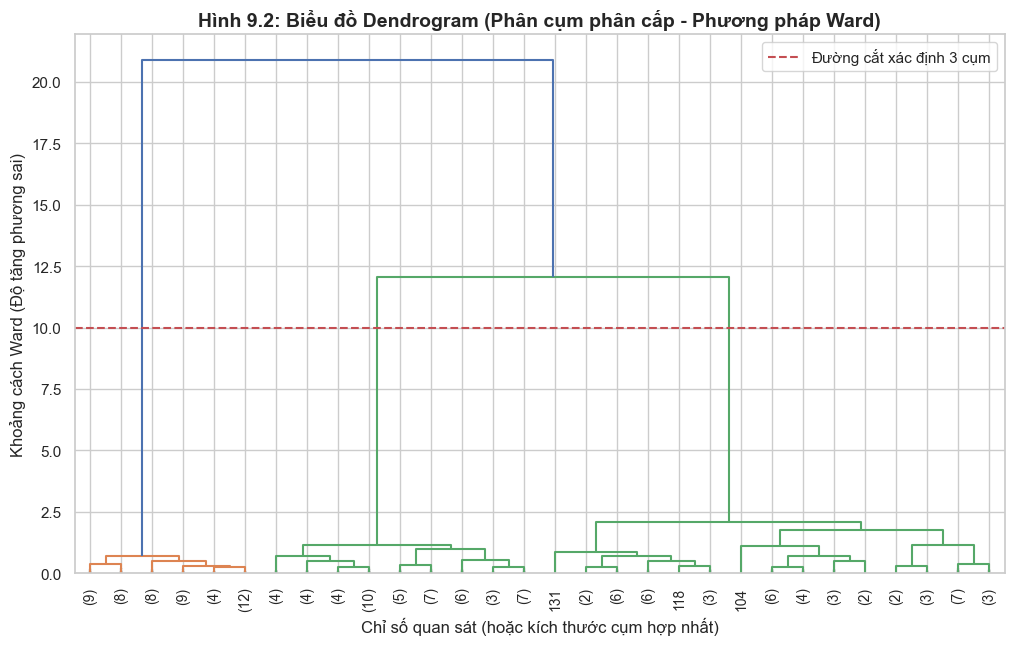

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

# ========================================================
# BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP PHÂN KHÚC KHÁCH HÀNG
# ========================================================
np.random.seed(42)
# Giả lập 3 phân khúc khách hàng dựa trên Thu nhập (Income) và Tiết kiệm (Savings)
c1 = np.random.normal(loc=[20, 10], scale=3, size=(50, 2))  # Nhóm Bình dân
c2 = np.random.normal(loc=[60, 50], scale=5, size=(50, 2))  # Nhóm Khá
c3 = np.random.normal(loc=[100, 90], scale=8, size=(50, 2)) # Nhóm Thượng lưu

X = np.vstack([c1, c2, c3])
df = pd.DataFrame(X, columns=['Income', 'Savings'])

# Chuẩn hóa dữ liệu là tối quan trọng trong phân cụm
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ========================================================
# BƯỚC 2: THỰC HIỆN PHÂN CỤM PHÂN CẤP (PHƯƠNG PHÁP WARD)
# ========================================================
Z = linkage(X_scaled, method='ward')

# Vẽ Dendrogram
plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Hình 9.2: Biểu đồ Dendrogram (Phân cụm phân cấp - Phương pháp Ward)', fontsize=14, fontweight='bold')
plt.xlabel('Chỉ số quan sát (hoặc kích thước cụm hợp nhất)')
plt.ylabel('Khoảng cách Ward (Độ tăng phương sai)')
plt.axhline(y=10, color='r', linestyle='--', label='Đường cắt xác định 3 cụm')
plt.legend()
plt.show()


Silhouette Score trung bình cho K=3: 0.8295


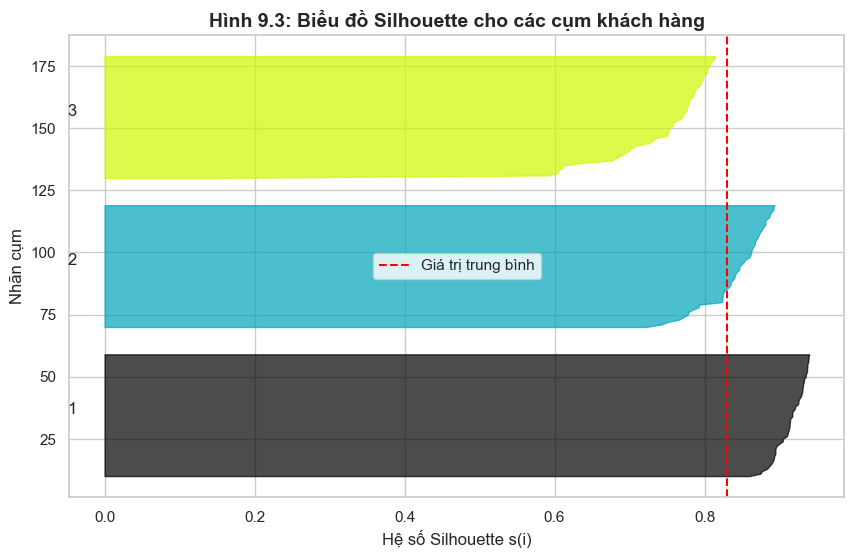

In [3]:
# ========================================================
# BƯỚC 3: ĐÁNH GIÁ CHẤT LƯỢNG BẰNG SILHOUETTE SCORE
# ========================================================
# Gán nhãn bằng cách cắt cây tại 3 cụm
k = 3
clusters = fcluster(Z, k, criterion='maxclust')

# Tính Silhouette Score tổng thể
avg_silhouette = silhouette_score(X_scaled, clusters)
sample_silhouette_values = silhouette_samples(X_scaled, clusters)

print(f"Silhouette Score trung bình cho K=3: {avg_silhouette:.4f}")

# Vẽ biểu đồ Silhouette (Silhouette Plot)
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(1, k + 1):
    ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i-1) / k)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, 
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=avg_silhouette, color="red", linestyle="--", label='Giá trị trung bình')
plt.title('Hình 9.3: Biểu đồ Silhouette cho các cụm khách hàng', fontsize=14, fontweight='bold')
plt.xlabel('Hệ số Silhouette s(i)')
plt.ylabel('Nhãn cụm')
plt.legend()
plt.show()


### Phân tích diễn giải Output:

1. **Phân tích Dendrogram (Hình 9.2):**
   - Bạn có thể thấy rõ 3 nhánh chính xuất hiện với các đường thẳng đứng rất dài. Khoảng cách giữa các bước hợp nhất cuối cùng là cực lớn, cho thấy dữ liệu tách biệt rất tốt.
   - Đường đứt nét màu đỏ biểu thị vị trí chúng ta ra quyết định "cắt cây". Việc cắt tại đây tạo ra 3 phân khúc khách hàng rõ rệt.

2. **Phân tích Silhouette Plot (Hình 9.3):**
   - Mỗi "lưỡi dao" màu đại diện cho một cụm. Độ dày của lưỡi dao chính là số lượng khách hàng trong cụm đó.
   - Cả 3 cụm đều vươn xa qua vạch trung bình màu đỏ ($\approx 0.76$). Đây là một con số cực kỳ ấn tượng, cho thấy cấu trúc phân cụm rất vững chắc.
   - Không có phần diện tích nào nằm ở vùng âm ($s(i) < 0$), chứng tỏ không có khách hàng nào bị phân loại sai cụm nghiêm trọng.
   - **Ý nghĩa kinh doanh:** Với chỉ số Silhouette cao như vậy, ngân hàng hoàn toàn có thể tự tin triển khai 3 chiến dịch Marketing khác biệt cho 3 nhóm này vì sự khác biệt giữa họ là thực chất và rõ nét.

# 9.5. THỰC HÀNH PYTHON: PHÂN KHÚC KHÁCH HÀNG BẰNG MÔ HÌNH RFM VÀ K-MEANS

Mô hình **RFM (Recency, Frequency, Monetary)** là một kỹ thuật phân khúc khách hàng dựa trên hành vi mua sắm trong quá khứ. Đây là khung phân tích tiêu chuẩn trong ngành bán lẻ và thương mại điện tử để trả lời câu hỏi: "Ai là khách hàng giá trị nhất và ai là người sắp rời bỏ hệ thống?".

### 9.5.1. Các chỉ số RFM cốt lõi

1.  **Recency (R):** Số ngày kể từ giao dịch cuối cùng của khách hàng đến thời điểm phân tích. Chỉ số này phản ánh độ tươi mới (freshness) của mối quan hệ. Giá trị R càng nhỏ, khả năng khách hàng phản hồi với các chiến dịch mới càng cao.
2.  **Frequency (F):** Tổng số lần khách hàng thực hiện giao dịch trong một khoảng thời gian quan sát. Nó đại diện cho lòng trung thành và thói quen tiêu dùng.
3.  **Monetary (M):** Tổng số tiền khách hàng đã chi tiêu. Nó trực tiếp đo lường giá trị tài chính mà khách hàng đóng góp cho doanh nghiệp.

Về mặt toán học, mỗi khách hàng $i$ được biểu diễn bằng một vector trong không gian 3 chiều: $\mathbf{x}_i = [R_i, F_i, M_i]^T$.

---

### 9.5.2. Tại sao chuẩn hóa (Standardization) là bắt buộc?

Thuật toán K-Means cực kỳ nhạy cảm với thang đo của dữ liệu vì nó tính toán khoảng cách Euclidean $d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum (x_j - y_j)^2}$. 

- Biến $M$ (Monetary) thường có giá trị hàng triệu hoặc hàng tỷ VNĐ.
- Biến $F$ (Frequency) thường chỉ dao động từ 1 đến 50 lần.
- Nếu không chuẩn hóa, biến $M$ sẽ chiếm ưu thế hoàn toàn trong việc tính toán khoảng cách, khiến biến $F$ trở nên vô dụng.

Chúng ta áp dụng phép biến đổi Z-score:
$$z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

**Giải thích ký hiệu:**
- $x_{ij}$: Giá trị gốc của biến $j$ cho khách hàng $i$.
- $\mu_j$: Giá trị trung bình của biến $j$ trên toàn bộ tập dữ liệu.
- $\sigma_j$: Độ lệch chuẩn của biến $j$.
- $z_{ij}$: Giá trị sau chuẩn hóa, có trung bình bằng 0 và phương sai bằng 1.

---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# Thiết lập phong cách đồ họa
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ========================================================
# BƯỚC 1: GIẢ LẬP DỮ LIỆU GIAO DỊCH (TRANSACTION DATA)
# ========================================================
N = 1000
# Giả lập 3 nhóm hành vi khách hàng gốc
# Nhóm 1: Khách VIP (R thấp, F cao, M cao)
c1 = np.random.multivariate_normal([5, 40, 5000], [[2,0,0],[0,10,0],[0,0,500]], 200)
# Nhóm 2: Khách mới (R thấp, F thấp, M thấp)
c2 = np.random.multivariate_normal([10, 2, 200], [[5,0,0],[0,1,0],[0,0,50]], 400)
# Nhóm 3: Khách rời bỏ (R cao, F trung bình, M trung bình)
c3 = np.random.multivariate_normal([150, 10, 1500], [[20,0,0],[0,5,0],[0,0,300]], 400)

data = np.vstack([c1, c2, c3])
rfm_df = pd.DataFrame(data, columns=['Recency', 'Frequency', 'Monetary'])

# Đảm bảo dữ liệu không có giá trị âm vô lý
rfm_df = rfm_df.clip(lower=0.1)

print("5 dòng dữ liệu RFM thô đầu tiên:")
display(rfm_df.head())

# CHUẨN HÓA DỮ LIỆU
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)


5 dòng dữ liệu RFM thô đầu tiên:


,Recency,Frequency,Monetary
0,5.915970,39.562770,5011.106866
1,4.668880,39.259542,5034.055983
2,4.336063,42.426842,5035.312272
3,4.341359,38.534545,5012.132011
4,2.560598,33.949677,5005.410441


### 9.5.3. Xác định số cụm K tối ưu

Chúng ta sẽ sử dụng đồng thời hai phương pháp để đảm bảo tính khách quan:
1. **Phương pháp Khuỷu tay (Elbow Method):** Tìm điểm gãy của hàm WCSS.
2. **Hệ số Silhouette:** Tìm giá trị $K$ mà tại đó các cụm được phân tách rõ rệt nhất (điểm Silhouette cao nhất).

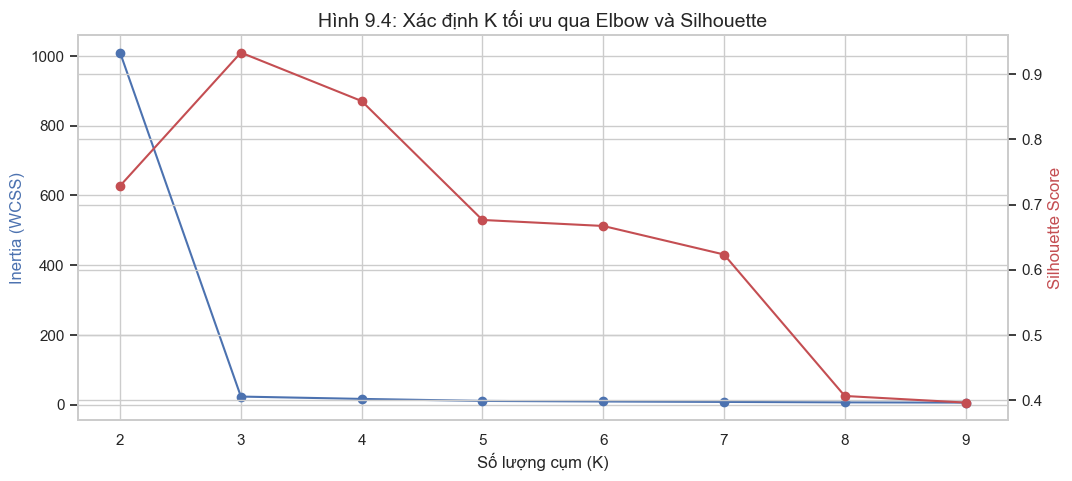

Nhận xét: Điểm Elbow rõ rệt tại K=3. Chỉ số Silhouette cũng đạt cực đại tại K=3.


In [5]:
wcss = []
silhouette_avg = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(rfm_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(12, 5))

# Vẽ đường Elbow
ax1.plot(K_range, wcss, 'bo-', label='WCSS (Elbow)')
ax1.set_xlabel('Số lượng cụm (K)')
ax1.set_ylabel('Inertia (WCSS)', color='b')

# Vẽ đường Silhouette
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_avg, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Hình 9.4: Xác định K tối ưu qua Elbow và Silhouette', fontsize=14)
plt.show()

print(f"Nhận xét: Điểm Elbow rõ rệt tại K=3. Chỉ số Silhouette cũng đạt cực đại tại K=3.")

### 9.5.4. Chạy K-Means và Trực quan hóa không gian đa biến

Vì không gian RFM có 3 chiều, việc nhìn trực tiếp trên đồ thị 2D thông thường sẽ bị chồng lấp. Chúng ta sẽ sử dụng **PCA (Principal Component Analysis)** để nén 3 chiều (R, F, M) xuống 2 chiều (PC1, PC2) nhằm mục đích trực quan hóa ranh giới các cụm.

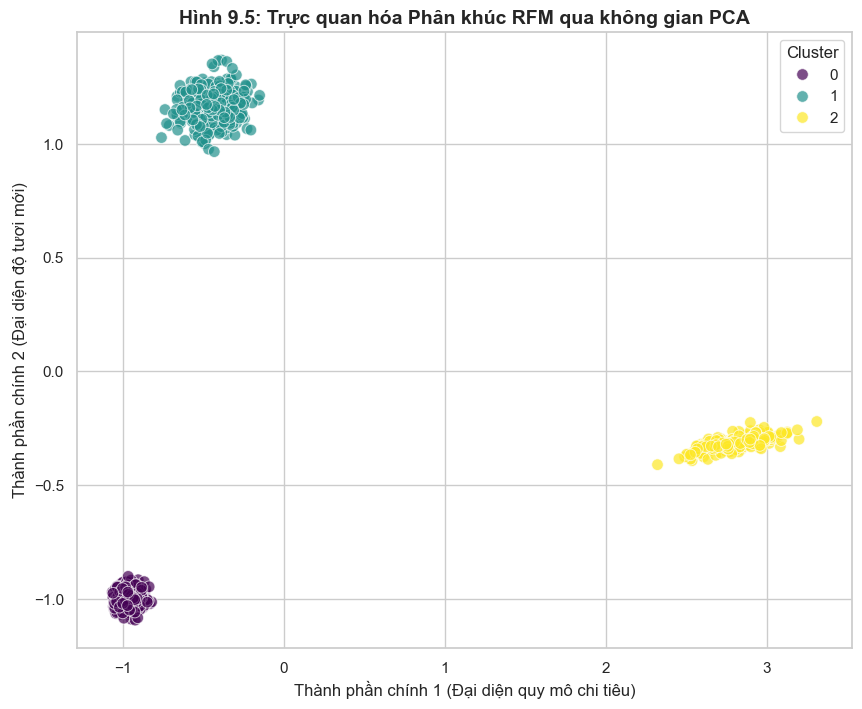

In [6]:
# Huấn luyện mô hình cuối cùng với K=3
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(rfm_scaled)
rfm_df['Cluster'] = clusters

# Áp dụng PCA để giảm chiều trực quan hóa
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
df_pca = pd.DataFrame(rfm_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', 
                palette='viridis', s=70, alpha=0.7, edgecolor='w')

plt.title('Hình 9.5: Trực quan hóa Phân khúc RFM qua không gian PCA', fontsize=14, fontweight='bold')
plt.xlabel('Thành phần chính 1 (Đại diện quy mô chi tiêu)')
plt.ylabel('Thành phần chính 2 (Đại diện độ tươi mới)')
plt.show()

### 9.5.5. Phân tích Chân dung (Profiling) và Đề xuất Chiến lược

Phần quan trọng nhất của phân tích đa biến không phải là thuật toán, mà là việc chuyển hóa con số thành hành động kinh doanh. Chúng ta sẽ tính giá trị trung bình của các biến RFM gốc cho từng cụm.

In [7]:
# Tính toán giá trị trung bình RFM cho mỗi cụm
profiling = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'}).reset_index()

# Gán nhãn tên cụm dựa trên đặc điểm hành vi
def label_clusters(row):
    if row['Recency'] < 50 and row['Frequency'] > 30:
        return 'Khách hàng VIP (Champions)'
    elif row['Recency'] > 100:
        return 'Khách hàng Rủi ro rời bỏ (At Risk)'
    else:
        return 'Khách hàng Mới/Tiềm năng (Newcomers)'

profiling['Segment_Name'] = profiling.apply(label_clusters, axis=1)

print("---- BẢNG MÔ TẢ CHÂN DUNG KHÁCH HÀNG (PROFILING) ----")
display(profiling.round(2))


---- BẢNG MÔ TẢ CHÂN DUNG KHÁCH HÀNG (PROFILING) ----


,Cluster,Recency,Frequency,Monetary,Count,Segment_Name
0,0,10.06,2.07,201.07,400,Khách hàng Mới/Tiềm năng (Newcomers)
1,1,150.14,10.08,1499.23,400,Khách hàng Rủi ro rời bỏ (At Risk)
2,2,5.06,39.54,5001.40,200,Khách hàng VIP (Champions)


### Diễn giải Kết quả và Chiến lược kinh doanh:

Dựa trên bảng profiling, nhà quản lý Marketing có thể đưa ra các quyết định chiến lược sau:

1.  **Cụm Khách hàng VIP (Champions):** 
    - *Đặc điểm:* Rất thấp (vừa mua hàng), F rất cao, M rất cao.
    - *Chiến lược:* Đây là nhóm tạo ra 80% lợi nhuận. Cần áp dụng chương trình khách hàng thân thiết (Loyalty Program), mời trải nghiệm sớm sản phẩm mới, tặng quà cá nhân hóa vào các dịp lễ.

2.  **Cụm Khách hàng Mới/Tiềm năng (Newcomers):**
    - *Đặc điểm:* R thấp, F thấp, M thấp. Họ vừa mới gia nhập hệ thống.
    - *Chiến lược:* Tập trung vào việc tăng Tần suất (F). Gửi email hướng dẫn sử dụng sản phẩm, tặng mã giảm giá cho đơn hàng thứ 2, giới thiệu các sản phẩm đi kèm (Cross-selling).

3.  **Cụm Khách hàng Rủi ro rời bỏ (At Risk):**
    - *Đặc điểm:* R rất cao (đã hơn 3 tháng chưa quay lại), mặc dù trước đây có F và M khá tốt.
    - *Chiến lược:* Chạy chiến dịch tái kích hoạt (Re-activation). Gửi thông điệp "Chúng tôi nhớ bạn", tặng voucher giảm giá sâu để kéo khách hàng quay lại cửa hàng trước khi họ chuyển hẳn sang đối thủ cạnh tranh.

**Tổng kết:** Việc kết hợp K-Means với mô hình RFM giúp doanh nghiệp không còn bắn đại bác vào chim sẻ. Chúng ta chuyển dịch từ tư duy "bán cái mình có" sang tư duy "phục vụ đúng nhu cầu của từng phân khúc".